This model will be the final model since everything else has been tried up to this point. This model will combine the carbohydrate estimator (Model 3 V3 DINOv2) and the ingredient estimator (Model 20) branch since it has quite good performance. This is combined with quite a simple fusion head and is similar to model 12 which combined the Model 3 V3 DINOv2 with the actual ingredients and it showed a marginally increase in performance.

Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

Configuration

In [ ]:
RGB_IMG_HEIGHT = 224
RGB_IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

COMBINER_EPOCHS = 400
COMBINER_LR = 1e-3
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv")

MODEL3_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
MODEL22_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator")
MODEL22_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = MODEL22_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

MODEL3_FINAL_MODEL = MODEL3_DIR / "final_model.keras"

loading metadata

In [ ]:
df = pd.read_csv(METADATA_CSV)

print("Loaded file:", METADATA_CSV)
print("Shape before processing:", df.shape)
print("Columns:", df.columns.tolist()[:40], "...")
display(df.head())

Loaded file: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv
Shape before processing: (3262, 205)
Columns: ['dish_id', 'total_mass', 'total_carb', 'split', 'source_cafe', 'num_ingredients', 'ingredient_list_str', 'ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy', 'ingr_bread', 'ingr_broccoli', 'ingr_brown_rice', 'ingr_brown_sugar', 'ingr_brownies', 'ingr_brussels_sprouts', 'ingr_bulgur', 'ingr_butter', 'ingr_buttermilk', 'ingr_cabbage', 'ingr_caesar_dressing', 'ingr_caesar_salad', 'ingr_cantaloupe'] ...


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_wheat_berry,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Creating dataset and paths

In [ ]:
required_cols = ["dish_id", "total_carb", "split", "source_cafe"]
missing_cols = [c for c in required_cols if c not in df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

ingredient_cols = [c for c in df.columns if c.startswith("ingr_")]

if len(ingredient_cols) == 0:
    raise ValueError("No ingredient columns found. Expected columns starting with 'ingr_'.")

print("Number of ingredient columns:", len(ingredient_cols))
print("First 20 ingredient columns:", ingredient_cols[:20])

Number of ingredient columns: 198
First 20 ingredient columns: ['ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy']


In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

df["dish_id"] = df["dish_id"].astype(str).str.strip()

df["rgb_path"] = df["dish_id"].progress_apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].progress_apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

  0%|          | 0/3262 [00:00<?, ?it/s]

  0%|          | 0/3262 [00:00<?, ?it/s]

Missing RGB images: 0


Checking for missing images

In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except Exception:
        return -1

df["rgb_size"] = df["rgb_path"].progress_apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after RGB filtering:")
print(df["split"].value_counts(dropna=False))
print("Total remaining:", len(df))
display(df.head())

  0%|          | 0/3262 [00:00<?, ?it/s]

Empty RGB files: 0

Remaining samples after RGB filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017


Splitting dataset

In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


Saving datasets

In [ ]:
train_csv = PREP_DIR / "train_model22_rgb_ingr.csv"
val_csv   = PREP_DIR / "val_model22_rgb_ingr.csv"
test_csv  = PREP_DIR / "test_model22_rgb_ingr.csv"
full_csv  = PREP_DIR / "full_model22_rgb_ingr.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/prep_files/train_model22_rgb_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/prep_files/val_model22_rgb_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/prep_files/test_model22_rgb_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/prep_files/full_model22_rgb_ingr.csv


SWITCH TO GPU FOR MODEL TRAINING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

Configuration

In [ ]:
RGB_IMG_HEIGHT = 224
RGB_IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

COMBINER_EPOCHS = 400
COMBINER_LR = 1e-3
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
MODEL3_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
MODEL20_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier")
MODEL22_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator")
MODEL22_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = MODEL22_DIR / "prep_files"

MODEL3_FINAL_MODEL = MODEL3_DIR / "final_model.keras"
MODEL20_FINAL_MODEL = MODEL20_DIR / "final_model.keras"

train_csv = PREP_DIR / "train_model22_rgb_ingr.csv"
val_csv   = PREP_DIR / "val_model22_rgb_ingr.csv"
test_csv  = PREP_DIR / "test_model22_rgb_ingr.csv"
full_csv  = PREP_DIR / "full_model22_rgb_ingr.csv"

Loading dataset back in

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

ingredient_cols = [c for c in train_df.columns if c.startswith("ingr_")]

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))
print("Number of ingredient columns:", len(ingredient_cols))

display(train_df.head())

Train: 2421
Val:   334
Test:  507
Number of ingredient columns: 198


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size
0,dish_1556572657,36.0,2.268,train,cafe1,1,olives,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412129
1,dish_1556573514,23.0,1.219,train,cafe1,1,mixed_greens,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,432908
2,dish_1556575014,62.0,3.906,train,cafe1,1,olives,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,409854
3,dish_1556575083,64.0,5.760,train,cafe1,1,brussels_sprouts,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,396942
4,dish_1556575124,28.0,0.952,train,cafe1,1,celery,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,404314


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=RGB_IMG_HEIGHT,
        target_width=RGB_IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_rgb_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    rgb_paths = dataframe["rgb_path"].astype(str).values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [ ]:
train_rgb_dataset = make_rgb_dataset(train_df, batch_size=BATCH_SIZE, shuffle=False)
val_rgb_dataset   = make_rgb_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_rgb_dataset  = make_rgb_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_rgb_dataset.take(1):
    print("Input keys:", batch_inputs.keys())
    print("RGB shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:", batch_labels.shape)

Input keys: dict_keys(['rgb_input'])
RGB shape: (16, 224, 224, 3)
Labels shape: (16,)


Loading pretrained models

In [ ]:
if MODEL3_FINAL_MODEL.exists():
    print("Loading RGB transformer from:", MODEL3_FINAL_MODEL)
    rgb_carb_model = keras.models.load_model(MODEL3_FINAL_MODEL)
else:
    raise FileNotFoundError(f"Could not find Model 3 V3 model at: {MODEL3_FINAL_MODEL}")

if MODEL20_FINAL_MODEL.exists():
    print("Loading ingredient estimator from:", MODEL20_FINAL_MODEL)
    ingredient_model = keras.models.load_model(MODEL20_FINAL_MODEL)
else:
    raise FileNotFoundError(f"Could not find Model 20 model at: {MODEL20_FINAL_MODEL}")

Loading RGB transformer from: /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/final_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 896 variables whereas the saved optimizer has 886 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loading ingredient estimator from: /content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/final_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 464 variables whereas the saved optimizer has 454 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
rgb_carb_model.summary()

Model: "rgb_only_dino_vit_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 1024)      │   304,631,808 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 257, 1024)      │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 911,932,549 (3.40 GB)

 Trainable params: 303,509,889 (1.13 GB)

 Non-trainable params: 1,402,880 (5.35 MB)

 Optimizer params: 607,019,780 (2.26 GB)

In [ ]:
ingredient_model.summary()

Model: "rgb_only_dinov2_base_ingredient_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 768)       │    86,777,856 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 257, 768)       │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingredient_output (Dense)       │ (None, 198)            │        25,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,999,764 (988.01 MB)

 Trainable params: 85,982,534 (328.00 MB)

 Non-trainable params: 1,052,160 (4.01 MB)

 Optimizer params: 171,965,070 (655.99 MB)

Creating predictions from each branch

In [ ]:
train_rgb_carb_preds = rgb_carb_model.predict(train_rgb_dataset, verbose=1).reshape(-1)
val_rgb_carb_preds   = rgb_carb_model.predict(val_rgb_dataset, verbose=1).reshape(-1)
test_rgb_carb_preds  = rgb_carb_model.predict(test_rgb_dataset, verbose=1).reshape(-1)

print("Train carb preds shape:", train_rgb_carb_preds.shape)
print("Val carb preds shape:  ", val_rgb_carb_preds.shape)
print("Test carb preds shape: ", test_rgb_carb_preds.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


151/152 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step 

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 1068s 7s/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 146s 7s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 215s 7s/step
Train carb preds shape: (2421,)
Val carb preds shape:   (334,)
Test carb preds shape:  (507,)


In [ ]:
train_ingr_preds = ingredient_model.predict(train_rgb_dataset, verbose=1)
val_ingr_preds   = ingredient_model.predict(val_rgb_dataset, verbose=1)
test_ingr_preds  = ingredient_model.predict(test_rgb_dataset, verbose=1)

print("Train ingredient preds shape:", train_ingr_preds.shape)
print("Val ingredient preds shape:  ", val_ingr_preds.shape)
print("Test ingredient preds shape: ", test_ingr_preds.shape)

152/152 ━━━━━━━━━━━━━━━━━━━━ 66s 418ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 377ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 407ms/step
Train ingredient preds shape: (2421, 198)
Val ingredient preds shape:   (334, 198)
Test ingredient preds shape:  (507, 198)


Creating combined dataset

In [ ]:
pred_ingredient_cols = [f"pred_{col}" for col in ingredient_cols]

base_cols = ["dish_id", "total_carb", "split", "source_cafe"]

train_combiner_df = train_df[base_cols].copy().reset_index(drop=True)
val_combiner_df   = val_df[base_cols].copy().reset_index(drop=True)
test_combiner_df  = test_df[base_cols].copy().reset_index(drop=True)

train_combiner_df["rgb_carb_pred"] = train_rgb_carb_preds
val_combiner_df["rgb_carb_pred"]   = val_rgb_carb_preds
test_combiner_df["rgb_carb_pred"]  = test_rgb_carb_preds

for i, col in enumerate(pred_ingredient_cols):
    train_combiner_df[col] = train_ingr_preds[:, i]
    val_combiner_df[col]   = val_ingr_preds[:, i]
    test_combiner_df[col]  = test_ingr_preds[:, i]

display(train_combiner_df.head())

/tmp/ipykernel_4177/4195661148.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_combiner_df[col] = train_ingr_preds[:, i]
/tmp/ipykernel_4177/4195661148.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_combiner_df[col]   = val_ingr_preds[:, i]
/tmp/ipykernel_4177/4195661148.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm

,dish_id,total_carb,split,source_cafe,rgb_carb_pred,pred_ingr_almonds,pred_ingr_apple,pred_ingr_artichokes,pred_ingr_arugula,pred_ingr_asparagus,...,pred_ingr_wheat_berry,pred_ingr_wheat_bread,pred_ingr_white_beans,pred_ingr_white_rice,pred_ingr_white_wine,pred_ingr_wild_rice,pred_ingr_wine,pred_ingr_yam,pred_ingr_yogurt,pred_ingr_zucchini
0,dish_1556572657,2.268,train,cafe1,2.041218,0.003237,4.618276e-07,2.267691e-06,6.570926e-10,0.000003,...,1.366452e-07,1.952985e-08,2.519221e-12,2.138120e-07,2.997094e-11,2.286739e-13,1.978370e-09,2.971382e-08,1.988422e-06,0.000002
1,dish_1556573514,1.219,train,cafe1,1.584430,0.001400,4.420539e-03,3.784934e-03,7.241180e-04,0.021378,...,8.600491e-05,7.758379e-06,3.372128e-06,1.698756e-05,2.777386e-07,4.196254e-08,3.065954e-04,4.087875e-05,1.062088e-03,0.000753
2,dish_1556575014,3.906,train,cafe1,3.690660,0.001655,2.432371e-07,2.519475e-06,2.510476e-09,0.000003,...,9.413976e-07,9.767230e-09,2.003109e-11,8.791426e-07,2.489979e-10,1.605229e-12,1.032282e-08,5.114276e-08,9.578351e-07,0.000005
3,dish_1556575083,5.760,train,cafe1,5.872280,0.000138,9.747376e-06,3.124530e-08,1.052347e-06,0.000001,...,3.201241e-06,8.337795e-10,2.432278e-11,9.107595e-07,5.040648e-11,9.297725e-13,3.563262e-07,2.200898e-05,5.886282e-08,0.000004
4,dish_1556575124,0.952,train,cafe1,0.847786,0.000085,3.147241e-04,3.101359e-04,8.202580e-07,0.000308,...,6.443245e-06,1.591473e-06,1.058992e-06,1.114436e-05,7.391897e-09,4.204719e-10,2.756730e-05,3.691517e-05,4.968368e-05,0.000944


In [ ]:
train_combiner_csv = MODEL22_DIR / "train_combiner_features_rgb_predicted_ingredients.csv"
val_combiner_csv   = MODEL22_DIR / "val_combiner_features_rgb_predicted_ingredients.csv"
test_combiner_csv  = MODEL22_DIR / "test_combiner_features_rgb_predicted_ingredients.csv"

train_combiner_df.to_csv(train_combiner_csv, index=False)
val_combiner_df.to_csv(val_combiner_csv, index=False)
test_combiner_df.to_csv(test_combiner_csv, index=False)

print("Saved combiner feature CSVs.")

Saved combiner feature CSVs.


In [ ]:
X_train_rgb = train_combiner_df[["rgb_carb_pred"]].values.astype("float32")
X_val_rgb   = val_combiner_df[["rgb_carb_pred"]].values.astype("float32")
X_test_rgb  = test_combiner_df[["rgb_carb_pred"]].values.astype("float32")

X_train_ingr = train_combiner_df[pred_ingredient_cols].values.astype("float32")
X_val_ingr   = val_combiner_df[pred_ingredient_cols].values.astype("float32")
X_test_ingr  = test_combiner_df[pred_ingredient_cols].values.astype("float32")

y_train = train_combiner_df["total_carb"].values.astype("float32")
y_val   = val_combiner_df["total_carb"].values.astype("float32")
y_test  = test_combiner_df["total_carb"].values.astype("float32")

In [ ]:
print("X_train_rgb:", X_train_rgb.shape)
print("X_train_ingr:", X_train_ingr.shape)
print("y_train:", y_train.shape)

X_train_rgb: (2421, 1)
X_train_ingr: (2421, 198)
y_train: (2421,)


In [ ]:
rgb_scaler = StandardScaler()

X_train_rgb_scaled = rgb_scaler.fit_transform(X_train_rgb).astype("float32")
X_val_rgb_scaled   = rgb_scaler.transform(X_val_rgb).astype("float32")
X_test_rgb_scaled  = rgb_scaler.transform(X_test_rgb).astype("float32")

joblib.dump(rgb_scaler, MODEL22_DIR / "rgb_scaler.joblib")
print("Saved RGB scaler.")

Saved RGB scaler.


Model 22 fusion architecture

In [ ]:
rgb_input = keras.Input(shape=(1,), name="rgb_pred_input")
ingredient_input = keras.Input(shape=(len(pred_ingredient_cols),), name="ingredient_input")

rgb_branch = layers.Dense(16, activation="relu")(rgb_input)
rgb_branch = layers.Dropout(0.1)(rgb_branch)

ingredient_branch = layers.Dense(128, activation="relu")(ingredient_input)
ingredient_branch = layers.Dropout(0.2)(ingredient_branch)
ingredient_branch = layers.Dense(64, activation="relu")(ingredient_branch)

fusion = layers.Concatenate()([rgb_branch, ingredient_branch])
fusion = layers.Dense(64, activation="relu")(fusion)
fusion = layers.Dropout(0.2)(fusion)
fusion = layers.Dense(32, activation="relu")(fusion)
output = layers.Dense(1, activation="linear", name="carb_output")(fusion)

model22 = keras.Model(
    inputs=[rgb_input, ingredient_input],
    outputs=output,
    name="model_22_neural_combiner"
)

Training model

In [ ]:
model22.compile(
    optimizer=keras.optimizers.Adam(learning_rate=COMBINER_LR),
    loss="mse",
    metrics=["mae", "mse"]
)

model22.summary()

Model: "model_22_neural_combiner"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ingredient_input    │ (None, 198)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_pred_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     25,472 │ ingredient_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         32 │ rgb_pred_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 16)        │          0 │ dense[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout_36[0][0], │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      5,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 64)        │          0 │ dense_3[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_38[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carb_output (Dense) │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,057 (160.38 KB)

 Trainable params: 41,057 (160.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model22_best_path = MODEL22_DIR / "best_model22_neural_combiner.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(model22_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=200,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=150,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history_model22 = model22.fit(
    {
        "rgb_pred_input": X_train_rgb_scaled,
        "ingredient_input": X_train_ingr
    },
    y_train,
    validation_data=(
        {
            "rgb_pred_input": X_val_rgb_scaled,
            "ingredient_input": X_val_ingr
        },
        y_val
    ),
    epochs=COMBINER_EPOCHS,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/400
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 444.7144 - mae: 14.8796 - mse: 444.7144
Epoch 1: val_loss improved from None to 67.76969, saving model to /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/best_model22_neural_combiner.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/best_model22_neural_combiner.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 397.5753 - mae: 11.2233 - mse: 397.5753 - val_loss: 67.7697 - val_mae: 6.1298 - val_mse: 67.7697 - learning_rate: 0.0010
Epoch 2/400
139/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 59.0934 - mae: 5.1603 - mse: 59.0934
Epoch 2: val_loss improved from 67.76969 to 46.41316, saving model to /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/best_model22_neural_combiner.weights.h5

Epoch 2: finished saving model to /content/dri

Evaluating model

In [ ]:
model22.load_weights(str(model22_best_path))
print("Loaded best Model 22 weights.")

Loaded best Model 22 weights.


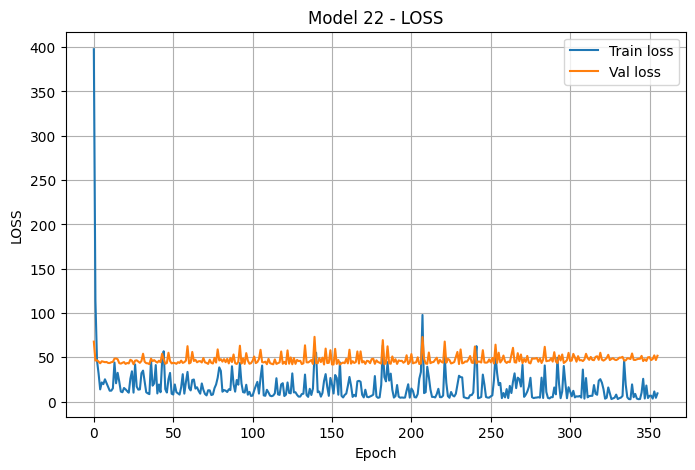

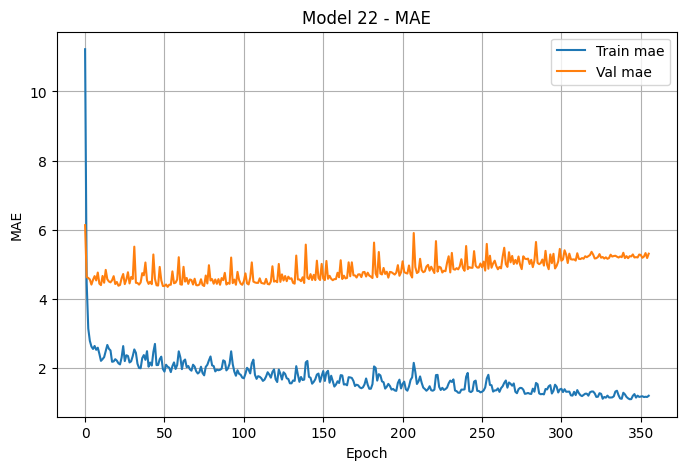

In [ ]:
for metric in ["loss", "mae"]:
    plt.figure(figsize=(8, 5))
    plt.plot(history_model22.history[metric], label=f"Train {metric}")
    plt.plot(history_model22.history[f"val_{metric}"], label=f"Val {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.title(f"Model 22 - {metric.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
train_preds = model22.predict(
    {
        "rgb_pred_input": X_train_rgb_scaled,
        "ingredient_input": X_train_ingr
    },
    verbose=1
).reshape(-1)

val_preds = model22.predict(
    {
        "rgb_pred_input": X_val_rgb_scaled,
        "ingredient_input": X_val_ingr
    },
    verbose=1
).reshape(-1)

test_preds = model22.predict(
    {
        "rgb_pred_input": X_test_rgb_scaled,
        "ingredient_input": X_test_ingr
    },
    verbose=1
).reshape(-1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


Calculating PMAE

In [ ]:
def compute_pmae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = np.mean(np.abs(y_true - y_pred))
    mean_true = np.mean(y_true)

    return float((mae / mean_true) * 100.0)

In [ ]:
def build_metric_row(model_name, y_train, train_pred, y_val, val_pred, y_test, test_pred):
    return {
        "model": model_name,

        "train_mae": float(mean_absolute_error(y_train, train_pred)),
        "train_mse": float(mean_squared_error(y_train, train_pred)),
        "train_rmse": float(np.sqrt(mean_squared_error(y_train, train_pred))),
        "train_r2": float(r2_score(y_train, train_pred)),
        "train_pmae": float(compute_pmae(y_train, train_pred)),

        "val_mae": float(mean_absolute_error(y_val, val_pred)),
        "val_mse": float(mean_squared_error(y_val, val_pred)),
        "val_rmse": float(np.sqrt(mean_squared_error(y_val, val_pred))),
        "val_r2": float(r2_score(y_val, val_pred)),
        "val_pmae": float(compute_pmae(y_val, val_pred)),

        "test_mae": float(mean_absolute_error(y_test, test_pred)),
        "test_mse": float(mean_squared_error(y_test, test_pred)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, test_pred))),
        "test_r2": float(r2_score(y_test, test_pred)),
        "test_pmae": float(compute_pmae(y_test, test_pred)),
    }

Building full metric dataframe

In [ ]:
results = []

results.append(build_metric_row(
    "RGB_only_baseline",
    y_train, train_combiner_df["rgb_carb_pred"].values,
    y_val,   val_combiner_df["rgb_carb_pred"].values,
    y_test,  test_combiner_df["rgb_carb_pred"].values
))

results.append(build_metric_row(
    "Model_22_Neural_Combiner",
    y_train, train_preds,
    y_val,   val_preds,
    y_test,  test_preds
))

results_df = pd.DataFrame(results).sort_values("val_mae", ascending=True).reset_index(drop=True)
display(results_df)

,model,train_mae,train_mse,train_rmse,train_r2,train_pmae,val_mae,val_mse,val_rmse,val_r2,val_pmae,test_mae,test_mse,test_rmse,test_r2,test_pmae
0,RGB_only_baseline,1.432568,6.344157,2.518761,0.988113,7.382401,4.529927,44.718330,6.687177,0.80366,24.100016,4.765221,57.263653,7.567275,0.811340,24.209099
1,Model_22_Neural_Combiner,1.532093,4.768230,2.183628,0.991066,7.895281,4.576953,41.932682,6.475545,0.81589,24.350206,4.618686,50.892933,7.133928,0.832329,23.464643


Saving results

In [ ]:
results_csv = MODEL22_DIR / "model22_comparison.csv"
results_df.to_csv(results_csv, index=False)
print("Saved results to:", results_csv)

Saved results to: /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/model22_comparison.csv


Saving model

In [ ]:
model22.save(MODEL22_DIR / "model22_neural_combiner.keras")
print("Saved Model 22 network combiner.")

Saved Model 22 network combiner.


In [ ]:
test_results_df = test_combiner_df.copy()

test_results_df["rgb_only_pred"] = test_combiner_df["rgb_carb_pred"]
test_results_df["model22_pred"] = test_preds

best_model_name = results_df.iloc[0]["model"]
print("Best model by validation MAE:", best_model_name)

Best model by validation MAE: RGB_only_baseline


In [ ]:
if best_model_name == "RGB_only_baseline":
    test_results_df["final_pred"] = test_results_df["rgb_only_pred"]
elif best_model_name == "Model_22_Neural_Combiner":
    test_results_df["final_pred"] = test_results_df["model22_pred"]

test_results_df["abs_error"] = np.abs(test_results_df["total_carb"] - test_results_df["final_pred"])
test_results_df["abs_error_rgb_only"] = np.abs(test_results_df["total_carb"] - test_results_df["rgb_only_pred"])

predictions_csv = MODEL22_DIR / "model22_test_predictions.csv"
test_results_df.to_csv(predictions_csv, index=False)

print("Saved test predictions to:", predictions_csv)
display(test_results_df.head())

Saved test predictions to: /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/model22_test_predictions.csv


,dish_id,total_carb,split,source_cafe,rgb_carb_pred,pred_ingr_almonds,pred_ingr_apple,pred_ingr_artichokes,pred_ingr_arugula,pred_ingr_asparagus,...,pred_ingr_wild_rice,pred_ingr_wine,pred_ingr_yam,pred_ingr_yogurt,pred_ingr_zucchini,rgb_only_pred,model22_pred,final_pred,abs_error,abs_error_rgb_only
0,dish_1556575327,10.618,test,cafe1,12.507236,0.009016,0.000126,0.000004,2.917965e-07,0.000008,...,7.206626e-10,6.879346e-07,0.000013,1.457757e-07,0.000081,12.507236,12.617384,12.507236,1.889236,1.889236
1,dish_1557861216,0.000,test,cafe1,1.025138,0.000008,0.000068,0.000049,2.531807e-07,0.000004,...,2.152842e-10,1.531195e-06,0.000007,3.537538e-04,0.000136,1.025138,2.983665,1.025138,1.025138,1.025138
2,dish_1557862345,0.000,test,cafe1,1.074629,0.000251,0.000006,0.000220,7.137177e-07,0.000052,...,1.876729e-10,4.616502e-06,0.000087,1.361917e-03,0.000048,1.074629,2.987030,1.074629,1.074629,1.074629
3,dish_1557862696,3.850,test,cafe1,3.543902,0.000012,0.000091,0.000028,4.340058e-08,0.000008,...,1.728327e-11,9.407403e-06,0.000038,3.801891e-03,0.000005,3.543902,3.917544,3.543902,0.306098,0.306098
4,dish_1557862738,0.000,test,cafe1,4.563577,0.000086,0.000062,0.000468,2.328329e-04,0.000453,...,2.230684e-07,2.086991e-04,0.003102,7.736096e-06,0.001087,4.563577,4.341109,4.563577,4.563577,4.563577


Top 10 best and worst dishes

In [ ]:
best_10 = test_results_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_results_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[[
    "dish_id", "total_carb",
    "rgb_only_pred", "final_pred", "abs_error"
]])

print("Top 10 worst predictions:")
display(worst_10[[
    "dish_id", "total_carb",
    "rgb_only_pred", "final_pred", "abs_error"
]])

Top 10 best predictions:


,dish_id,total_carb,rgb_only_pred,final_pred,abs_error
54,dish_1558376801,0.795000,0.798961,0.798961,0.003961
336,dish_1563909507,8.186116,8.204203,8.204203,0.018087
351,dish_1563998323,35.302532,35.333618,35.333618,0.031086
289,dish_1562790775,1.519515,1.554551,1.554551,0.035036
61,dish_1558461760,2.379000,2.339917,2.339917,0.039083
489,dish_1567007751,9.660000,9.620059,9.620059,0.039941
477,dish_1566850031,25.780001,25.725090,25.725090,0.054911
17,dish_1557937758,18.932001,18.995913,18.995913,0.063912
429,dish_1565898158,10.249402,10.319388,10.319388,0.069986
122,dish_1559578551,0.322000,0.244068,0.244068,0.077932


Top 10 worst predictions:


,dish_id,total_carb,rgb_only_pred,final_pred,abs_error
178,dish_1560801020,61.690983,27.431894,27.431894,34.259089
179,dish_1560801041,63.245892,29.548124,29.548124,33.697768
149,dish_1560367952,45.956913,13.091601,13.091601,32.865312
177,dish_1560800988,61.249092,28.556852,28.556852,32.692240
150,dish_1560367980,47.243912,16.448000,16.448000,30.795912
247,dish_1562009934,62.243580,33.657280,33.657280,28.586300
313,dish_1563478751,54.133282,25.818369,25.818369,28.314913
446,dish_1566328805,85.054001,57.366875,57.366875,27.687126
318,dish_1563551220,79.790924,52.106049,52.106049,27.684875
325,dish_1563566909,46.750000,20.878225,20.878225,25.871775


Saving summary

In [ ]:
summary = {
    "model_name": "Model 22 - ViT overhead RGB + predicted ingredients from Model 20",
    "num_ingredient_features": int(len(pred_ingredient_cols)),
    "best_model_by_val_mae": str(best_model_name),
    "results_sorted_by_val_mae": results_df.to_dict(orient="records")
}

summary_path = MODEL22_DIR / "model22_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)

Saved summary to: /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/model22_summary.json
